In [31]:
import pandas as pd


In [32]:
import pandas as pd
import numpy as np 
import seaborn as sns 
from sklearn.model_selection import train_test_split

In [33]:
df = pd.read_csv('klachten.csv')

In [34]:
y = df['Product']

In [35]:
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=y
)

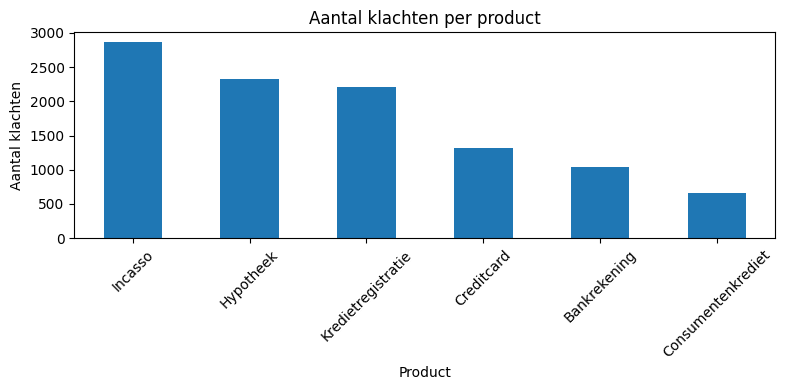

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
train_df["Product"].value_counts().plot(kind="bar")

plt.title("Aantal klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.xticks(rotation=45)   # draait de labels zodat je ze kunt lezen
plt.tight_layout()
plt.show()

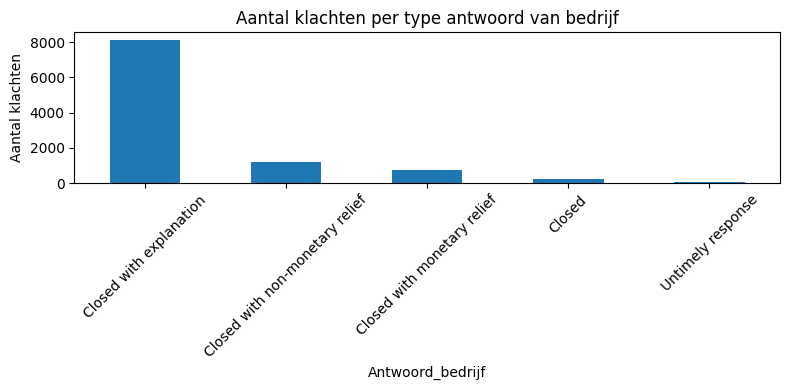

In [39]:
plt.figure(figsize=(8,4))
train_df["Antwoord_bedrijf"].value_counts().plot(kind="bar")

plt.title("Aantal klachten per type antwoord van bedrijf")
plt.xlabel("Antwoord_bedrijf")
plt.ylabel("Aantal klachten")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

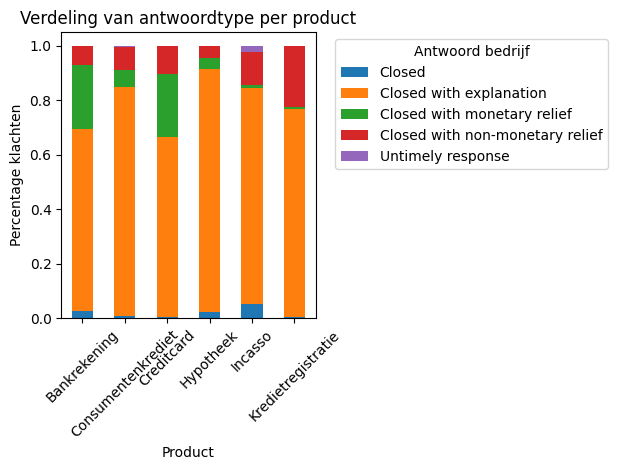

In [42]:
base_df = train_df.copy()

# kruistabel: percentage per antwoordtype binnen elk product
ct = pd.crosstab(
    base_df["Product"],
    base_df["Antwoord_bedrijf"],
    normalize="index"   # per product naar percentage
)

plt.figure(figsize=(8,4))
ct.plot(kind="bar", stacked=True)

plt.title("Verdeling van antwoordtype per product")
plt.xlabel("Product")
plt.ylabel("Percentage klachten")
plt.xticks(rotation=45)
plt.legend(title="Antwoord bedrijf", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

<Figure size 800x400 with 0 Axes>

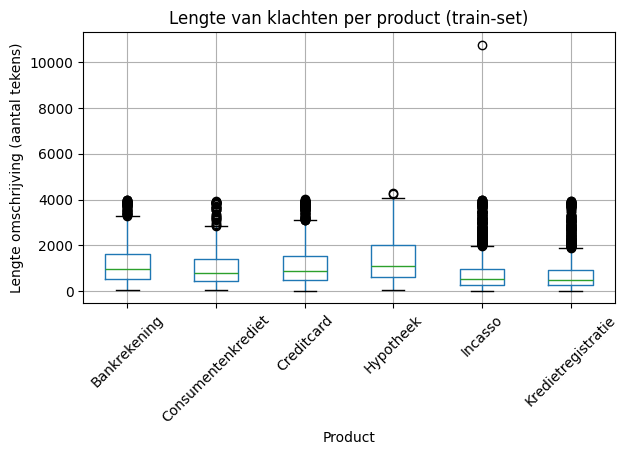

In [43]:
base_df = train_df.copy()

# tekstlengte in tekens
base_df["Omschrijving_len"] = base_df["Omschrijving"].astype(str).str.len()

plt.figure(figsize=(8,4))
base_df.boxplot(column="Omschrijving_len", by="Product")

plt.title("Lengte van klachten per product (train-set)")
plt.suptitle("")  # extra pandas-titel weg
plt.xlabel("Product")
plt.ylabel("Lengte omschrijving (aantal tekens)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

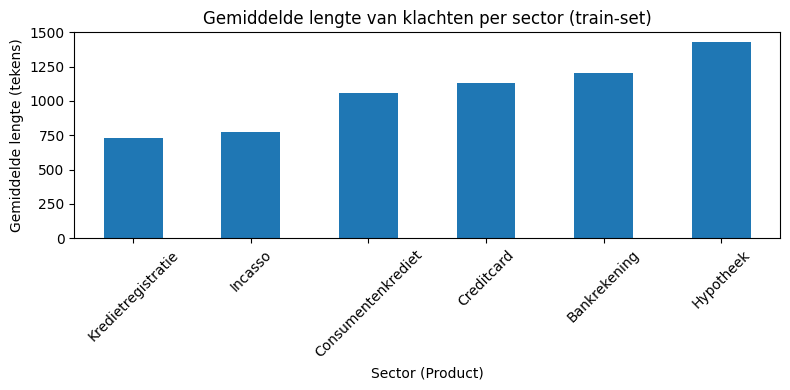

In [44]:
base_df = train_df.copy()
base_df["Omschrijving_len"] = base_df["Omschrijving"].astype(str).str.len()

mean_lengths = (
    base_df
    .groupby("Product")["Omschrijving_len"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,4))
mean_lengths.plot(kind="bar")

plt.title("Gemiddelde lengte van klachten per sector (train-set)")
plt.xlabel("Sector (Product)")
plt.ylabel("Gemiddelde lengte (tekens)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

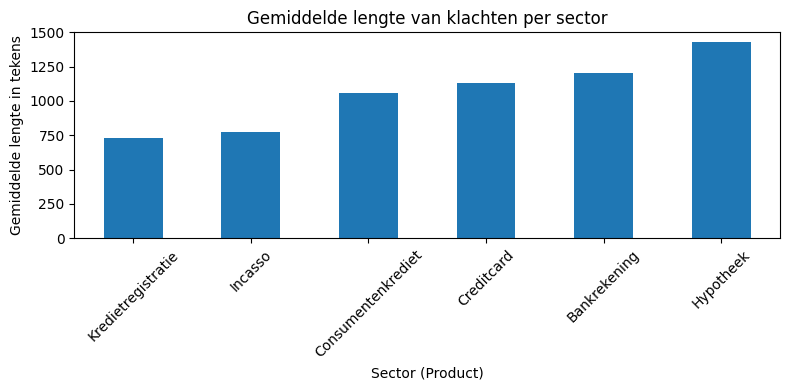

In [46]:
base_df = train_df.copy()
base_df["Omschrijving_len"] = base_df["Omschrijving"].astype(str).str.len()

mean_lengths = (
    base_df
    .groupby("Product")["Omschrijving_len"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,4))
mean_lengths.plot(kind="bar")

plt.title("Gemiddelde lengte van klachten per sector")
plt.xlabel("Sector (Product)")
plt.ylabel("Gemiddelde lengte in tekens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()